# Proposal — LNG Planner EDA (통합)

> 발표용 *서사 한 줄*:
> **LNG 는 (1) 즉시 원하는 만큼 못 움직이고, (2) 작은 gap 까지 다 따라가면 over-commit 생긴다.**
> → planner 가 *단순 gap-tracker* 가 아니라 *ramp-aware + deadband 기반 결정자* 여야 하는 이유.

- **§1** = LNG ramp 제약 — 호기별 상승/하강 비대칭 분포
- **§2** = Deadband trade-off — shortfall vs over-commit sweep

데이터 (사전 캐시 로드):
- `data/processed/lng_hourly_ramp.parquet` — 4 년 hourly LNG 운전 데이터 (운전 중 mw>5 만, 약 13만 rows / 1.3 MB)
- `pv/eda_lng_planner/A_deadband_results.csv` — planner 재실행 true sweep 결과

> 캐시 부재 시: `python pv/eda_lng_planner/_build_cache.py` 한 번 실행 (4년 CSV → parquet, ~30s)


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ── 컬러 팔레트 (메인 = 파랑) ─────────────────────────────────
BLUE_LIGHT = '#a6cee3'
BLUE_MAIN  = '#1f77b4'
BLUE_DEEP  = '#08519c'
BLUE_NAVY  = '#08306b'
ACCENT_RED = '#d62728'
GRAY_LINE  = '#888888'

# ── ROOT 자동 검색 (kernel CWD 가 어디든 동작) ────────────────
def find_root(marker='CLAUDE.md', start=None):
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / marker).exists():
            return cand
    raise FileNotFoundError(f'project root not found (marker={marker})')

ROOT = find_root()
print(f'ROOT: {ROOT}')

LNG_UNITS = ['CG1','CG2','CG3','CG4','CG5','CG6','CG7','CG8','CS1','CS2']

# ── 캐시 로드 ─────────────────────────────────────────────────
CACHE = ROOT / 'data/processed/lng_hourly_ramp.parquet'
if not CACHE.exists():
    raise FileNotFoundError(
        f'cache not found: {CACHE}\n'
        f'→ run once:  python pv/eda_lng_planner/_build_cache.py'
    )
running = pd.read_parquet(CACHE)
print(f'loaded cache: {len(running):,} rows  '
      f'({running.unit.nunique()} units, '
      f'{running.datetime_kst.min().date()} ~ {running.datetime_kst.max().date()})')


ROOT: D:\pv_backup
loaded cache: 129,551 rows  (10 units, 2022-01-01 ~ 2025-12-31)


---

## §1. LNG 는 즉시 원하는 만큼 움직일 수 없다

**핵심 메시지**: LNG 는 PV 부족분을 보완할 수 있지만, *호기별 출력 변화 속도에 제약* 이 있어 *즉각적인 추종이 어렵다*.
특히 baseload 호기는 *천천히 올리고 더 천천히 내려가는* 비대칭 구조 → 한 번 올라간 출력이 회복 후에도 잔류 = over-commit 의 구조적 원인.

데이터: 4 년 hourly LNG 운전 데이터 (운전 중 `mw>5` 행만) → 호기별 시간당 `ΔMW` 분포.


In [2]:
# === 호기별 ramp 통계 (p50/p90/p99) ===
stats = []
for u in LNG_UNITS:
    s = running[running.unit == u]
    pos = s.loc[s.mw_diff > 0, 'mw_diff'].values
    neg = -s.loc[s.mw_diff < 0, 'mw_diff'].values
    if len(pos) == 0 or len(neg) == 0:
        continue
    stats.append({
        'unit': u,
        'type': 'GT' if u.startswith('CG') else 'ST',
        'n_up': len(pos), 'n_dn': len(neg),
        'up_p50':  float(np.percentile(pos, 50)),
        'up_p90':  float(np.percentile(pos, 90)),
        'up_p99':  float(np.percentile(pos, 99)),
        'dn_p50':  float(np.percentile(neg, 50)),
        'dn_p90':  float(np.percentile(neg, 90)),
        'dn_p99':  float(np.percentile(neg, 99)),
    })
sdf = pd.DataFrame(stats)
sdf['ratio_p90'] = (sdf.up_p90 / sdf.dn_p90).round(2)
sdf['ratio_p99'] = (sdf.up_p99 / sdf.dn_p99).round(2)
print('[호기별 ramp 통계 — 운전 중 4년]')
print(sdf.round(2).to_string(index=False))


[호기별 ramp 통계 — 운전 중 4년]
unit type  n_up  n_dn  up_p50  up_p90  up_p99  dn_p50  dn_p90  dn_p99  ratio_p90  ratio_p99
 CG1   GT  7663  6117    0.34   13.17   49.56    0.33    2.99   45.42       4.40       1.09
 CG2   GT  4473  3586    0.43   28.92   63.74    0.38   11.18   51.81       2.59       1.23
 CG3   GT  7250  5896    0.37   14.66   48.10    0.34    3.70   47.94       3.96       1.00
 CG4   GT  3837  3101    0.38   27.51   62.47    0.37    6.76   52.36       4.07       1.19
 CG5   GT  5383  4506    0.32   12.40   58.61    0.32    2.54   47.43       4.89       1.24
 CG6   GT  8861  7813    0.28   18.21   53.06    0.26    1.87   48.15       9.74       1.10
 CG7   GT  6756  5784    0.30   25.71   61.65    0.27    3.19   56.02       8.07       1.10
 CG8   GT  8376  7151    0.31   19.03   54.68    0.27    2.39   53.58       7.97       1.02
 CS1   ST  7436  7243    0.56   29.28   70.10    0.45    7.42  101.65       3.95       0.69
 CS2   ST  8837  9350    0.41   18.52   70.40    0.32   

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


...

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


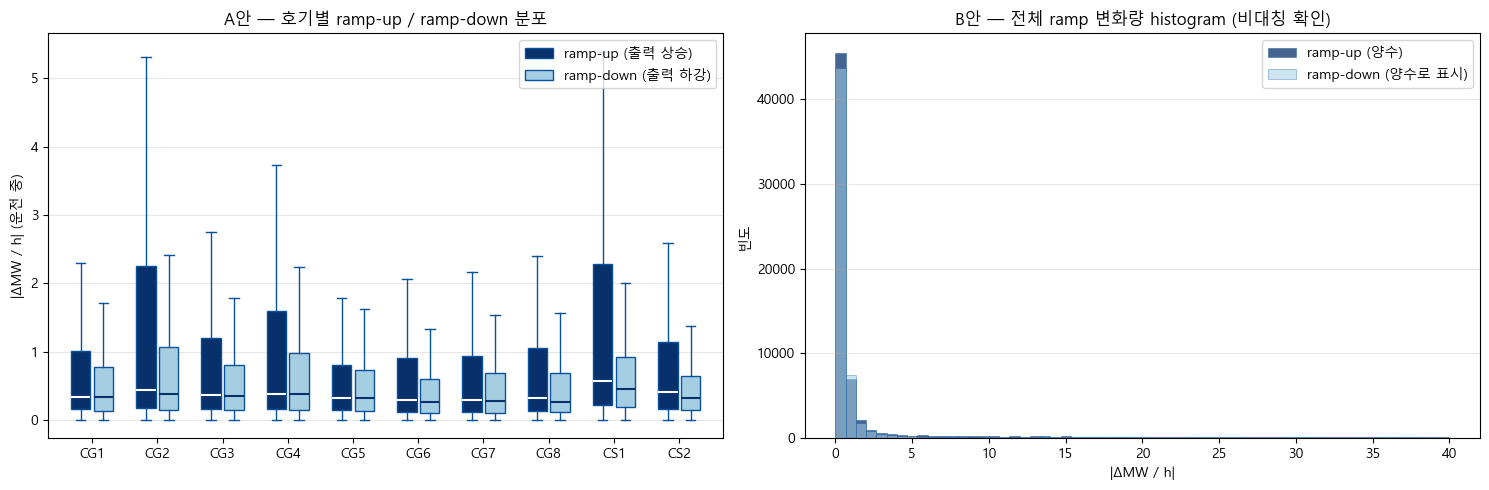

In [3]:
# === 그래프: A안 (호기별 boxplot) + B안 (전체 histogram) ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

xs = np.arange(len(LNG_UNITS))
w  = 0.35
up_data = [running.loc[(running.unit==u) & (running.mw_diff>0), 'mw_diff'].values for u in LNG_UNITS]
dn_data = [-running.loc[(running.unit==u) & (running.mw_diff<0), 'mw_diff'].values for u in LNG_UNITS]

# A안 — 호기별 boxplot
bp1 = ax1.boxplot(up_data, positions=xs-w/2, widths=w*0.85, showfliers=False,
                  patch_artist=True, boxprops=dict(facecolor=BLUE_NAVY,  edgecolor=BLUE_DEEP),
                  medianprops=dict(color='white', linewidth=1.5),
                  whiskerprops=dict(color=BLUE_DEEP),
                  capprops=dict(color=BLUE_DEEP))
bp2 = ax1.boxplot(dn_data, positions=xs+w/2, widths=w*0.85, showfliers=False,
                  patch_artist=True, boxprops=dict(facecolor=BLUE_LIGHT, edgecolor=BLUE_DEEP),
                  medianprops=dict(color=BLUE_NAVY, linewidth=1.5),
                  whiskerprops=dict(color=BLUE_DEEP),
                  capprops=dict(color=BLUE_DEEP))
ax1.set_xticks(xs); ax1.set_xticklabels(LNG_UNITS, rotation=0)
ax1.set_ylabel('|ΔMW / h| (운전 중)')
ax1.set_title('A안 — 호기별 ramp-up / ramp-down 분포')
ax1.legend([bp1['boxes'][0], bp2['boxes'][0]],
           ['ramp-up (출력 상승)', 'ramp-down (출력 하강)'], loc='upper right')
ax1.grid(alpha=0.3, axis='y')

# B안 — 전체 aggregate histogram
ax2.hist(running.loc[running.mw_diff>0, 'mw_diff'].values,
         bins=60, range=(0, 40), alpha=0.75, color=BLUE_NAVY,
         label='ramp-up (양수)', edgecolor=BLUE_DEEP, linewidth=0.4)
ax2.hist(-running.loc[running.mw_diff<0, 'mw_diff'].values,
         bins=60, range=(0, 40), alpha=0.55, color=BLUE_LIGHT,
         label='ramp-down (양수로 표시)', edgecolor=BLUE_DEEP, linewidth=0.4)
ax2.set_xlabel('|ΔMW / h|')
ax2.set_ylabel('빈도')
ax2.set_title('B안 — 전체 ramp 변화량 histogram (비대칭 확인)')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


→ **모델 함의**:
- **호기별 차이**: GT (CG1~8) 와 ST (CS1, CS2) 가 ramp 분포 다름 — 단순히 *총 부족분 / 호기수* 로 배분 불가
- **상승/하강 비대칭**: baseload 호기 (CG6, CS2) 는 p90 기준 *상승 한도 ≈ 18~19 MW/h vs 하강 한도 ≈ 1.9~2.7 MW/h* (약 7~10x 차이)
- **운영 의미**: 한 번 올라간 출력은 PV 가 회복해도 *느린 하강 한도 만큼만* 내려갈 수 있음 → *잔류 출력 = over-commit 구조적 원인*
- 모델이 만든 인위적 결과 X. *실제 4년 운영 데이터의 분포 그대로*.

> **발표용 표현**: LNG 호기별로 시간당 출력 조정 가능 폭이 다르고, 특히 상승보다 하강이 훨씬 느린 비대칭 구조다. 따라서 PV 부족분을 단순히 총량 기준으로 배분할 수 없고, 호기별 ramp 여력을 고려해 결정해야 한다.


---

## §2. 작은 gap 까지 모두 대응하면 over-commit 이 생긴다

**핵심 메시지**: 모든 PV gap 을 LNG 가 따라가면 *부족분은 줄지만* PV 회복 뒤 *과대 보충이 잔류* → over-commit 증가.
→ planner 가 *deadband* 를 두고 *계통 자체 흡수 구간* 과 *LNG 대응 구간* 을 나눠야 하는 이유.

데이터: `thermal_planner_v4` 의 1년 시뮬레이션을 *DEADBAND={0, 2, 4, 6, 8} MW* 로 재실행한 결과
(`pv/eda_lng_planner/A_deadband_results.csv`).
이는 *post-hoc KPI 재계산* 이 아니라 *planner 자체를 재실행한 true sweep*.


In [4]:
# === True sweep 결과 로드 ===
sweep_path = ROOT / 'pv/eda_lng_planner/A_deadband_results.csv'
sweep = pd.read_csv(sweep_path)
print('[True sweep — planner 재실행 결과]')
print(sweep.round(1).to_string(index=False))


[True sweep — planner 재실행 결과]
 DEADBAND  shortfall  over_commit  ratio  total_dE  state_INC
        0     1197.3        769.6    0.6    5670.2        115
        2      698.9        700.2    1.0    3485.4        115
        4      441.5        640.1    1.4    2448.1        115
        6      303.3        582.6    1.9    1897.1        115
        8      224.4        535.3    2.4    1602.2        115


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


...

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


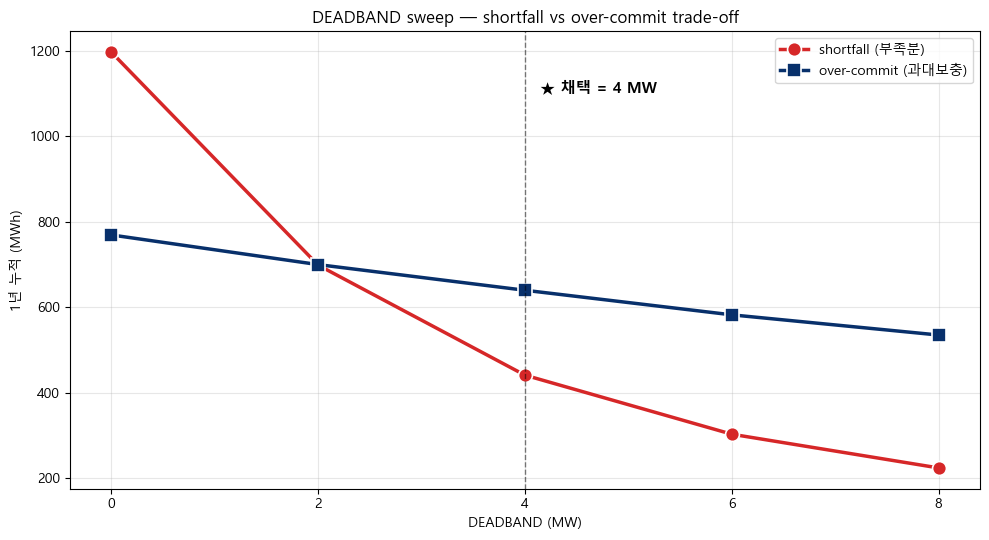


[balance 비율 = over-commit / shortfall]
  1 에 가까울수록 균형
 DEADBAND  shortfall  over_commit  ratio
        0    1197.35       769.58   0.64
        2     698.89       700.16   1.00
        4     441.45       640.10   1.45
        6     303.27       582.59   1.92
        8     224.36       535.35   2.39


In [5]:
# === 그래프: shortfall vs over-commit trade-off ===
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(sweep.DEADBAND, sweep.shortfall, 'o-',
        color=ACCENT_RED, lw=2.5, markersize=10,
        label='shortfall (부족분)', markeredgecolor='white', markeredgewidth=1.2)
ax.plot(sweep.DEADBAND, sweep.over_commit, 's-',
        color=BLUE_NAVY, lw=2.5, markersize=10,
        label='over-commit (과대보충)', markeredgecolor='white', markeredgewidth=1.2)

# 채택 deadband=4 마커
ax.axvline(4, color='black', lw=1, ls='--', alpha=0.5)
ymax = max(sweep.shortfall.max(), sweep.over_commit.max())
ax.text(4.15, ymax*0.92, '★ 채택 = 4 MW',
        fontsize=11, color='black', fontweight='bold')

ax.set_xlabel('DEADBAND (MW)')
ax.set_ylabel('1년 누적 (MWh)')
ax.set_title('DEADBAND sweep — shortfall vs over-commit trade-off')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xticks(sweep.DEADBAND.unique())

plt.tight_layout(); plt.show()

# 보조: ratio (over/short) 표시
print('\n[balance 비율 = over-commit / shortfall]')
print('  1 에 가까울수록 균형')
print(sweep[['DEADBAND','shortfall','over_commit','ratio']].round(2).to_string(index=False))


→ **모델 함의**:
- **DEADBAND=0** (계통 흡수 없음 가정): 작은 변동까지 LNG 가 추종 → *over-commit 폭증* (비현실적)
- **DEADBAND=4** (★ 채택, LNG ≈50% 담당 가정): shortfall · over-commit *균형 영역* (ratio ≈ 1.45)
- **DEADBAND=8+** (계통 흡수 과대): shortfall 도 줄지만 *LNG 책임 자체가 사라짐* → PoC 의미 약화
- 그래프의 *plateau 위치* 가 deadband 채택의 근거 — 우연이 아니라 *trade-off 곡선의 균형점*

> **발표용 표현**: deadband 가 작으면 작은 오차까지 LNG 가 대응하므로 shortfall 은 줄지만 over-commit 이 커진다. 반대로 deadband 가 너무 크면 LNG 대응이 늦어져 shortfall 이 커진다. 따라서 적절한 deadband 를 설정해 계통 자체 흡수 구간과 LNG 대응 구간을 나누는 것이 필요하다.


---

## 최종 요약 — 왜 planner 가 단순 gap-tracker 가 아닌가

| 관측 | 결정 |
|---|---|
| §1 호기별 ramp 비대칭 (상승 vs 하강 7~10x) | planner 가 *호기별 ramp 여력* 을 고려해 배분 |
| §2 DEADBAND trade-off (shortfall ↔ over-commit) | *계통 자체 흡수 구간* (DEADBAND=4) 을 두고 LNG 책임분만 처리 |

본 PoC 의 LNG planner 는 *PV gap 의 단순 합산* 이 아니라, *(1) 호기별 ramp 한도 + (2) deadband 기반 책임 분담* 의 결정 구조로 설계됨.
